<a href="https://colab.research.google.com/github/amankumarres/Genotypic-AMR-Prediction-Pipeline/blob/main/Genotypic_AMR_Prediction_Klebsiella_pneumoniae_NTUH_K2044.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Genotypic AMR Prediction in *Klebsiella pneumoniae*

## Project Overview

This project aims to characterize antimicrobial resistance (AMR) determinants in *Klebsiella pneumoniae* NTUH-K2044 using genome sequence data and AMRFinderPlus.

The analysis will identify AMR determinants and investigate their genomic context, along with virulence-associated and stress/metal-resistance features.

## Why *Klebsiella pneumoniae* NTUH-K2044?

*Klebsiella pneumoniae* was selected as a representative bacterial case study for genomic AMR characterization. The selected NTUH-K2044 genome provides chromosome and plasmid sequences, allowing AMR determinants and other genomic features to be examined in their genomic context.

The purpose is not to claim that *K. pneumoniae* is the only or best organism for AMR research. Other organisms such as *Escherichia coli* and *Salmonella* would also be suitable for similar analyses.

## Objectives

- Detect antimicrobial resistance determinants.
- Classify detected AMR determinants.
- Determine their genomic locations.
- Identify virulence-associated features.
- Identify stress/metal-resistance features.
- Investigate mutation-specific AMR records.
- Generate structured result tables and visualizations.
- Interpret genotypic findings while distinguishing them from phenotypic antimicrobial susceptibility.

## Expected Outcome

The final analysis will produce:

- An AMR evidence table.
- Genomic-location information for detected AMR determinants.
- Virulence-associated feature results.
- Stress/metal-resistance feature results.
- Mutation-specific analysis results.
- Summary statistics and visualizations.
- A documented interpretation of the genomic findings.

## Important Limitation

Genotypic detection of an AMR determinant does not by itself confirm phenotypic antimicrobial resistance. Phenotypic antimicrobial susceptibility testing would be required to experimentally validate the predicted resistance profile.

In [1]:
# Step 1: Install Conda (Software Package Manager) inside Google Colab environment
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...


In [2]:
%%bash

# Step 2: Install AMRFinderPlus

conda create -y -n amrfinder -c conda-forge -c bioconda ncbi-amrfinderplus

source /usr/local/etc/profile.d/conda.sh
conda activate amrfinder

echo "= AMRFinderPlus Version ="
amrfinder --version

Retrieving notices: - \ | done
Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: \ | done

## Package Plan ##

  environment location: /usr/local/envs/amrfinder

  added / updated specs:
    - ncbi-amrfinderplus


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    blast-2.17.0               |       hb02a186_1       152.8 MB  bioconda
    bzip2-1.0.8                |      hda65f42_10         252 KB  conda-forge
    c-ares-1.34.8              |       hebe6cf0_2         223 KB  conda-forge
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    curl-8.21.0                |       ha042cf0_5         190 KB  conda-forge
    entrez-direct-26.0         |       h1079eea_0        15.4 MB  bioconda
    gsl-2.7                    |       he838d99_0         3.2 MB  conda-forge
    hmmer-3.4                  |       h7d74f8d_5         8.2 MB 

In [3]:
# Step 3: Download NTUH-K2044 genome sequences from NCBI

import os

os.makedirs("data", exist_ok=True)

# Chromosome
!wget -q https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/009/885/GCA_000009885.1_ASM988v1/GCA_000009885.1_ASM988v1_genomic.fna.gz -O data/NTUH-K2044_genome.fna.gz

# Extract FASTA
!gunzip -f data/NTUH-K2044_genome.fna.gz

print("Genome downloaded successfully.")

# Check file
!ls -lh data/NTUH-K2044_genome.fna

Genome downloaded successfully.
-rw-r--r-- 1 root root 5.3M Aug  4  2014 data/NTUH-K2044_genome.fna


In [4]:
# Step 4A: Download AMRFinderPlus database

!source /usr/local/etc/profile.d/conda.sh && conda activate amrfinder && \
amrfinder -u

Running: amrfinder -u
The number of threads cannot be greater than 2 on this computer
The current number of threads is 4, reducing to 2
Software directory: /usr/local/envs/amrfinder/bin/
Software version: 4.2.7
Running: /usr/local/envs/amrfinder/bin/amrfinder_update -d /usr/local/envs/amrfinder/share/amrfinderplus/data
Looking up the published databases at https://ftp.ncbi.nlm.nih.gov/pathogen/Antimicrobial_resistance/AMRFinderPlus/database/
Looking for the target directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1/
Running: /usr/local/envs/amrfinder/bin/amrfinder_index /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1/
Indexing
amrfinder_index took 5 seconds to complete
amrfinder_update took 17 seconds to complete
Database directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1
Database version: 2026-08-07.1
amrfinder took 17 seconds to complete


In [1]:
# Step 4: Run AMRFinderPlus on NTUH-K2044 genome

!source /usr/local/etc/profile.d/conda.sh && conda activate amrfinder && \
amrfinder \
-n data/NTUH-K2044_genome.fna \
-o amr_results.tsv

print("AMRFinderPlus analysis completed.")

Running: amrfinder -n data/NTUH-K2044_genome.fna -o amr_results.tsv
The number of threads cannot be greater than 2 on this computer
The current number of threads is 4, reducing to 2
Software directory: /usr/local/envs/amrfinder/bin/
Software version: 4.2.7
Database directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1
Database version: 2026-08-07.1
AMRFinder translated nucleotide search
  - include -O ORGANISM, --organism ORGANISM option to add mutation searches and suppress common proteins
Running tblastn
Making report
amrfinder took 322 seconds to complete
AMRFinderPlus analysis completed.


In [2]:
# Step 5: Verify AMRFinderPlus output

import pandas as pd
import os

print("Checking AMRFinderPlus output...")

print("File exists:", os.path.exists("amr_results.tsv"))

df = pd.read_csv("amr_results.tsv", sep="\t")

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 results:")
display(df.head())

Checking AMRFinderPlus output...
File exists: True
Number of rows: 4
Number of columns: 22

Column names:
['Protein id', 'Contig id', 'Start', 'Stop', 'Strand', 'Element symbol', 'Element name', 'Scope', 'Type', 'Subtype', 'Class', 'Subclass', 'Method', 'Target length', 'Reference sequence length', '% Coverage of reference', '% Identity to reference', 'Alignment length', 'Closest reference accession', 'Closest reference name', 'HMM accession', 'HMM description']

First 5 results:


,Protein id,Contig id,Start,Stop,Strand,Element symbol,Element name,Scope,Type,Subtype,...,Method,Target length,Reference sequence length,% Coverage of reference,% Identity to reference,Alignment length,Closest reference accession,Closest reference name,HMM accession,HMM description
0,NaN,AP006725.1,699857,700273,+,fosA,FosA5 family fosfomycin resistance glutathione...,core,AMR,AMR,...,EXACTX,139,139,100.0,100.0,139,WP_004146118.1,FosA5 family fosfomycin resistance glutathione...,NaN,NaN
1,NaN,AP006725.1,2524621,2525478,-,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,core,AMR,AMR,...,ALLELEX,286,286,100.0,100.0,286,WP_004176269.1,broad-spectrum class A beta-lactamase SHV-11,NaN,NaN
2,NaN,AP006725.1,4036312,4037484,+,oqxA,multidrug efflux RND transporter periplasmic a...,core,AMR,AMR,...,EXACTX,391,391,100.0,100.0,391,WP_002914189.1,multidrug efflux RND transporter periplasmic a...,NaN,NaN
3,NaN,AP006725.1,4037511,4040660,+,oqxB19,multidrug efflux RND transporter permease subu...,core,AMR,AMR,...,ALLELEX,1050,1050,100.0,100.0,1050,WP_004149399.1,multidrug efflux RND transporter permease subu...,NaN,NaN


In [3]:
# Step 6: Create AMR summary table

amr = df[df["Type"] == "AMR"].copy()

amr_summary = amr[
    [
        "Element symbol",
        "Element name",
        "Contig id",
        "Start",
        "Stop",
        "Class",
        "Subclass",
        "Method",
        "% Coverage of reference",
        "% Identity to reference"
    ]
].copy()

print("===== AMR SUMMARY =====")
display(amr_summary)

===== AMR SUMMARY =====


,Element symbol,Element name,Contig id,Start,Stop,Class,Subclass,Method,% Coverage of reference,% Identity to reference
0,fosA,FosA5 family fosfomycin resistance glutathione...,AP006725.1,699857,700273,FOSFOMYCIN,FOSFOMYCIN,EXACTX,100.0,100.0
1,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,AP006725.1,2524621,2525478,BETA-LACTAM,BETA-LACTAM,ALLELEX,100.0,100.0
2,oqxA,multidrug efflux RND transporter periplasmic a...,AP006725.1,4036312,4037484,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,NITROFURANTOIN/PHENICOL/QUINOLONE/TIGECYCLINE,EXACTX,100.0,100.0
3,oqxB19,multidrug efflux RND transporter permease subu...,AP006725.1,4037511,4040660,PHENICOL/QUINOLONE,PHENICOL/QUINOLONE,ALLELEX,100.0,100.0


In [4]:
# Step 7: Summarize genomic locations of AMR determinants

location_summary = amr[
    [
        "Element symbol",
        "Element name",
        "Contig id",
        "Start",
        "Stop",
        "Strand"
    ]
].copy()

print("===== AMR GENOMIC LOCATIONS =====")
display(location_summary)

===== AMR GENOMIC LOCATIONS =====


,Element symbol,Element name,Contig id,Start,Stop,Strand
0,fosA,FosA5 family fosfomycin resistance glutathione...,AP006725.1,699857,700273,+
1,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,AP006725.1,2524621,2525478,-
2,oqxA,multidrug efflux RND transporter periplasmic a...,AP006725.1,4036312,4037484,+
3,oqxB19,multidrug efflux RND transporter permease subu...,AP006725.1,4037511,4040660,+


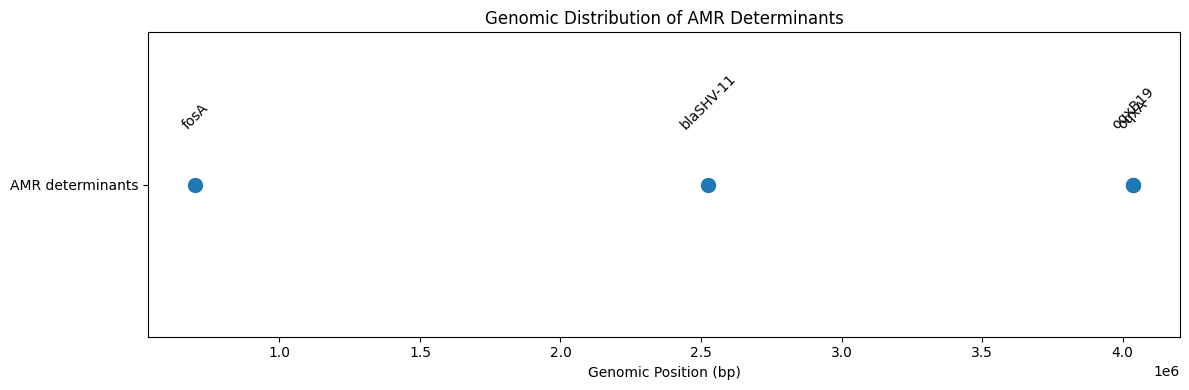

In [5]:
# Step 8: Visualize AMR genomic locations

import matplotlib.pyplot as plt

plot_data = location_summary.sort_values("Start").copy()

plt.figure(figsize=(12, 4))

plt.scatter(
    plot_data["Start"],
    [1] * len(plot_data),
    s=100
)

for _, row in plot_data.iterrows():
    plt.text(
        row["Start"],
        1.02,
        row["Element symbol"],
        ha="center",
        rotation=45
    )

plt.xlabel("Genomic Position (bp)")
plt.yticks([1], ["AMR determinants"])
plt.title("Genomic Distribution of AMR Determinants")
plt.tight_layout()

plt.show()

In [6]:
# Step 9: Identify virulence-associated features

virulence = df[df["Type"] == "VIRULENCE"].copy()

print("===== VIRULENCE-ASSOCIATED FEATURES =====")
print("Number of virulence-associated features:", len(virulence))

if len(virulence) > 0:
    virulence_summary = virulence[
        [
            "Element symbol",
            "Element name",
            "Contig id",
            "Start",
            "Stop",
            "Class",
            "Subclass",
            "Method"
        ]
    ].copy()

    display(virulence_summary)
else:
    print("No virulence-associated features detected.")

===== VIRULENCE-ASSOCIATED FEATURES =====
Number of virulence-associated features: 0
No virulence-associated features detected.


In [7]:
# Step 10: Check all feature types detected by AMRFinderPlus

print("===== DETECTED FEATURE TYPES =====")

type_counts = df["Type"].value_counts(dropna=False)

display(type_counts)

===== DETECTED FEATURE TYPES =====


,count
Type,
AMR,4


In [8]:
# Step 11: Create the final AMR evidence table

amr_summary = amr[
    [
        "Element symbol",
        "Element name",
        "Class",
        "Subclass",
        "Method",
        "% Coverage of reference",
        "% Identity to reference",
        "Contig id",
        "Start",
        "Stop"
    ]
].copy()

print("===== FINAL AMR EVIDENCE TABLE =====")

display(amr_summary)

===== FINAL AMR EVIDENCE TABLE =====


,Element symbol,Element name,Class,Subclass,Method,% Coverage of reference,% Identity to reference,Contig id,Start,Stop
0,fosA,FosA5 family fosfomycin resistance glutathione...,FOSFOMYCIN,FOSFOMYCIN,EXACTX,100.0,100.0,AP006725.1,699857,700273
1,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,BETA-LACTAM,BETA-LACTAM,ALLELEX,100.0,100.0,AP006725.1,2524621,2525478
2,oqxA,multidrug efflux RND transporter periplasmic a...,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,NITROFURANTOIN/PHENICOL/QUINOLONE/TIGECYCLINE,EXACTX,100.0,100.0,AP006725.1,4036312,4037484
3,oqxB19,multidrug efflux RND transporter permease subu...,PHENICOL/QUINOLONE,PHENICOL/QUINOLONE,ALLELEX,100.0,100.0,AP006725.1,4037511,4040660


In [9]:
# Step 12: Summarize AMR determinants by resistance class

class_summary = (
    amr.groupby("Class")
       .size()
       .reset_index(name="Number of determinants")
       .sort_values("Number of determinants", ascending=False)
)

print("===== AMR CLASS SUMMARY =====")
display(class_summary)

===== AMR CLASS SUMMARY =====


,Class,Number of determinants
0,BETA-LACTAM,1
1,FOSFOMYCIN,1
2,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,1
3,PHENICOL/QUINOLONE,1


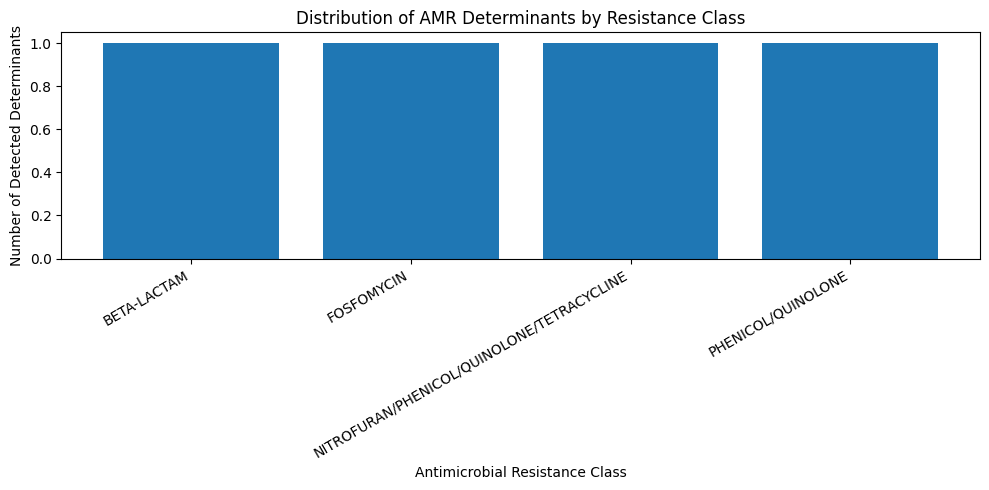

In [10]:
# Step 13: Visualize AMR determinants by resistance class

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    class_summary["Class"],
    class_summary["Number of determinants"]
)

plt.xlabel("Antimicrobial Resistance Class")
plt.ylabel("Number of Detected Determinants")
plt.title("Distribution of AMR Determinants by Resistance Class")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [11]:
# Step 14: Final genomic-location table

location_summary = amr[
    [
        "Element symbol",
        "Element name",
        "Contig id",
        "Start",
        "Stop",
        "Strand"
    ]
].copy()

print("===== AMR GENOMIC LOCATIONS =====")
display(location_summary)

===== AMR GENOMIC LOCATIONS =====


,Element symbol,Element name,Contig id,Start,Stop,Strand
0,fosA,FosA5 family fosfomycin resistance glutathione...,AP006725.1,699857,700273,+
1,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,AP006725.1,2524621,2525478,-
2,oqxA,multidrug efflux RND transporter periplasmic a...,AP006725.1,4036312,4037484,+
3,oqxB19,multidrug efflux RND transporter permease subu...,AP006725.1,4037511,4040660,+


In [12]:
# Step 15: Save final AMR results as CSV files

import os

os.makedirs("results", exist_ok=True)

# Save AMR evidence table
amr_summary.to_csv(
    "results/AMR_evidence_table.csv",
    index=False
)

# Save genomic locations
location_summary.to_csv(
    "results/AMR_genomic_locations.csv",
    index=False
)

# Save class summary
class_summary.to_csv(
    "results/AMR_class_summary.csv",
    index=False
)

print("===== RESULTS SAVED =====")
print("1. results/AMR_evidence_table.csv")
print("2. results/AMR_genomic_locations.csv")
print("3. results/AMR_class_summary.csv")

===== RESULTS SAVED =====
1. results/AMR_evidence_table.csv
2. results/AMR_genomic_locations.csv
3. results/AMR_class_summary.csv


In [13]:
# Step 16: Inspect AMRFinderPlus output fields

print("===== AMRFINDERPLUS OUTPUT COLUMNS =====")

for i, column in enumerate(df.columns, start=1):
    print(i, ":", column)

print("\n===== DETECTION METHODS =====")
display(df["Method"].value_counts(dropna=False))

===== AMRFINDERPLUS OUTPUT COLUMNS =====
1 : Protein id
2 : Contig id
3 : Start
4 : Stop
5 : Strand
6 : Element symbol
7 : Element name
8 : Scope
9 : Type
10 : Subtype
11 : Class
12 : Subclass
13 : Method
14 : Target length
15 : Reference sequence length
16 : % Coverage of reference
17 : % Identity to reference
18 : Alignment length
19 : Closest reference accession
20 : Closest reference name
21 : HMM accession
22 : HMM description

===== DETECTION METHODS =====


,count
Method,
EXACTX,2
ALLELEX,2


In [14]:
# Step 17: Check available AMRFinderPlus organism names

!source /usr/local/etc/profile.d/conda.sh && conda activate amrfinder && \
amrfinder --list_organisms

Running: amrfinder --list_organisms
The number of threads cannot be greater than 2 on this computer
The current number of threads is 4, reducing to 2
Software directory: /usr/local/envs/amrfinder/bin/
Software version: 4.2.7
Database directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1
Database version: 2026-08-07.1

Available --organism options: Acinetobacter_baumannii, Bordetella_pertussis, Burkholderia_cepacia, Burkholderia_mallei, Burkholderia_pseudomallei, Campylobacter, Citrobacter_freundii, Clostridioides_difficile, Corynebacterium_diphtheriae, Enterobacter_asburiae, Enterobacter_cloacae, Enterococcus_faecalis, Enterococcus_faecium, Escherichia, Haemophilus_influenzae, Helicobacter_pylori, Klebsiella_oxytoca, Klebsiella_pneumoniae, Neisseria_gonorrhoeae, Neisseria_meningitidis, Pseudomonas_aeruginosa, Salmonella, Serratia_marcescens, Staphylococcus_aureus, Staphylococcus_epidermidis, Staphylococcus_pseudintermedius, Streptococcus_agalactiae, Streptococcus_p

In [15]:
# Step 18: Find Klebsiella organism options

!source /usr/local/etc/profile.d/conda.sh && conda activate amrfinder && \
amrfinder --list_organisms | tr ',' '\n' | grep -i klebsiella

Running: amrfinder --list_organisms
The number of threads cannot be greater than 2 on this computer
The current number of threads is 4, reducing to 2
Software directory: /usr/local/envs/amrfinder/bin/
Software version: 4.2.7
Database directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1
Database version: 2026-08-07.1
amrfinder took 0 seconds to complete
 Klebsiella_oxytoca
 Klebsiella_pneumoniae


In [16]:
# Step 19: Run organism-specific AMRFinderPlus analysis

!source /usr/local/etc/profile.d/conda.sh && conda activate amrfinder && \
amrfinder \
-n data/NTUH-K2044_genome.fna \
-o amr_results_kp.tsv \
-O Klebsiella_pneumoniae

print("Organism-specific AMRFinderPlus analysis completed.")

Running: amrfinder -n data/NTUH-K2044_genome.fna -o amr_results_kp.tsv -O Klebsiella_pneumoniae
The number of threads cannot be greater than 2 on this computer
The current number of threads is 4, reducing to 2
Software directory: /usr/local/envs/amrfinder/bin/
Software version: 4.2.7
Database directory: /usr/local/envs/amrfinder/share/amrfinderplus/data/2026-08-07.1
Database version: 2026-08-07.1
AMRFinder translated nucleotide and mutation search
Running tblastn
Running blastn
Making report
amrfinder took 362 seconds to complete
Organism-specific AMRFinderPlus analysis completed.


In [17]:
# Step 20: Load organism-specific AMRFinderPlus results

import pandas as pd

df_kp = pd.read_csv("amr_results_kp.tsv", sep="\t")

print("===== ORGANISM-SPECIFIC AMRFINDERPLUS RESULTS =====")
print("Number of rows:", len(df_kp))
print("Number of columns:", len(df_kp.columns))

print("\nDetected feature types:")
display(df_kp["Type"].value_counts(dropna=False))

print("\nDetection methods:")
display(df_kp["Method"].value_counts(dropna=False))

print("\nFirst results:")
display(df_kp)

===== ORGANISM-SPECIFIC AMRFINDERPLUS RESULTS =====
Number of rows: 4
Number of columns: 22

Detected feature types:


,count
Type,
AMR,4



Detection methods:


,count
Method,
EXACTX,2
ALLELEX,2



First results:


,Protein id,Contig id,Start,Stop,Strand,Element symbol,Element name,Scope,Type,Subtype,...,Method,Target length,Reference sequence length,% Coverage of reference,% Identity to reference,Alignment length,Closest reference accession,Closest reference name,HMM accession,HMM description
0,NaN,AP006725.1,699857,700273,+,fosA,FosA5 family fosfomycin resistance glutathione...,core,AMR,AMR,...,EXACTX,139,139,100.0,100.0,139,WP_004146118.1,FosA5 family fosfomycin resistance glutathione...,NaN,NaN
1,NaN,AP006725.1,2524621,2525478,-,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,core,AMR,AMR,...,ALLELEX,286,286,100.0,100.0,286,WP_004176269.1,broad-spectrum class A beta-lactamase SHV-11,NaN,NaN
2,NaN,AP006725.1,4036312,4037484,+,oqxA,multidrug efflux RND transporter periplasmic a...,core,AMR,AMR,...,EXACTX,391,391,100.0,100.0,391,WP_002914189.1,multidrug efflux RND transporter periplasmic a...,NaN,NaN
3,NaN,AP006725.1,4037511,4040660,+,oqxB19,multidrug efflux RND transporter permease subu...,core,AMR,AMR,...,ALLELEX,1050,1050,100.0,100.0,1050,WP_004149399.1,multidrug efflux RND transporter permease subu...,NaN,NaN


In [18]:
# Step 21: Check for point-mutation detections

print("===== POINT MUTATION CHECK =====")

print("\nSubtype counts:")
display(df_kp["Subtype"].value_counts(dropna=False))

print("\nMethod counts:")
display(df_kp["Method"].value_counts(dropna=False))

# Show any mutation/POINT records
mutation_hits = df_kp[
    (df_kp["Subtype"].astype(str).str.upper() == "POINT") |
    (df_kp["Method"].astype(str).str.upper().str.startswith("POINT"))
].copy()

print("\n===== POINT MUTATION RESULTS =====")
print("Number of point-mutation records:", len(mutation_hits))

if len(mutation_hits) > 0:
    display(
        mutation_hits[
            [
                "Element symbol",
                "Element name",
                "Contig id",
                "Start",
                "Stop",
                "Class",
                "Subclass",
                "Method",
                "% Coverage of reference",
                "% Identity to reference"
            ]
        ]
    )
else:
    print("No point-mutation records detected.")

===== POINT MUTATION CHECK =====

Subtype counts:


,count
Subtype,
AMR,4



Method counts:


,count
Method,
EXACTX,2
ALLELEX,2



===== POINT MUTATION RESULTS =====
Number of point-mutation records: 0
No point-mutation records detected.


In [19]:
# Step 22: Create final AMR evidence table

amr_final = df_kp[df_kp["Type"] == "AMR"].copy()

amr_evidence = amr_final[
    [
        "Element symbol",
        "Element name",
        "Contig id",
        "Start",
        "Stop",
        "Strand",
        "Class",
        "Subclass",
        "Method",
        "% Coverage of reference",
        "% Identity to reference"
    ]
].copy()

print("===== FINAL AMR EVIDENCE TABLE =====")
print("Total AMR determinants:", len(amr_evidence))

display(amr_evidence)

===== FINAL AMR EVIDENCE TABLE =====
Total AMR determinants: 4


,Element symbol,Element name,Contig id,Start,Stop,Strand,Class,Subclass,Method,% Coverage of reference,% Identity to reference
0,fosA,FosA5 family fosfomycin resistance glutathione...,AP006725.1,699857,700273,+,FOSFOMYCIN,FOSFOMYCIN,EXACTX,100.0,100.0
1,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,AP006725.1,2524621,2525478,-,BETA-LACTAM,BETA-LACTAM,ALLELEX,100.0,100.0
2,oqxA,multidrug efflux RND transporter periplasmic a...,AP006725.1,4036312,4037484,+,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,NITROFURANTOIN/PHENICOL/QUINOLONE/TIGECYCLINE,EXACTX,100.0,100.0
3,oqxB19,multidrug efflux RND transporter permease subu...,AP006725.1,4037511,4040660,+,PHENICOL/QUINOLONE,PHENICOL/QUINOLONE,ALLELEX,100.0,100.0


In [20]:
# Step 23: Functional summary of detected AMR determinants

functional_summary = amr_evidence[
    [
        "Element symbol",
        "Element name",
        "Class",
        "Subclass",
        "Method",
        "% Coverage of reference",
        "% Identity to reference"
    ]
].copy()

print("===== FUNCTIONAL AMR SUMMARY =====")
display(functional_summary)

===== FUNCTIONAL AMR SUMMARY =====


,Element symbol,Element name,Class,Subclass,Method,% Coverage of reference,% Identity to reference
0,fosA,FosA5 family fosfomycin resistance glutathione...,FOSFOMYCIN,FOSFOMYCIN,EXACTX,100.0,100.0
1,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,BETA-LACTAM,BETA-LACTAM,ALLELEX,100.0,100.0
2,oqxA,multidrug efflux RND transporter periplasmic a...,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,NITROFURANTOIN/PHENICOL/QUINOLONE/TIGECYCLINE,EXACTX,100.0,100.0
3,oqxB19,multidrug efflux RND transporter permease subu...,PHENICOL/QUINOLONE,PHENICOL/QUINOLONE,ALLELEX,100.0,100.0


**Genetic Analysis**

Analysis using the AMRFinderPlus on the genome sequence of Klebsiella pneumoniae NTUH-K2044 revealed the presence of four AMR determinants, which are fosA, blaSHV-11, oqxA, and oqxB19.

The identified AMR determinants include those that confer resistance to fosfomycin, beta-lactam, and multidrug classes. In the current analysis, all the detected AMR determinants show 100% coverage and identity to their respective reference sequences.

The above information shows the presence of genotypic AMR determinants in the analyzed organism. Antimicrobial susceptibility test phenotypically was not done; hence, the above result cannot be used to infer phenotypic resistance.

In [21]:
# Step 25: Analyze genomic context of AMR determinants

genomic_context = amr[
    [
        "Element symbol",
        "Element name",
        "Contig id",
        "Start",
        "Stop",
        "Strand"
    ]
].copy()

# Sort by contig and genomic position
genomic_context = genomic_context.sort_values(
    ["Contig id", "Start"]
).reset_index(drop=True)

print("===== AMR GENOMIC CONTEXT =====")
display(genomic_context)

# Calculate distance between consecutive AMR determinants
genomic_context["Distance_from_previous_bp"] = (
    genomic_context["Start"] -
    genomic_context["Stop"].shift(1)
)

print("===== DISTANCE BETWEEN AMR DETERMINANTS =====")
display(
    genomic_context[
        [
            "Element symbol",
            "Contig id",
            "Start",
            "Stop",
            "Distance_from_previous_bp"
        ]
    ]
)

===== AMR GENOMIC CONTEXT =====


,Element symbol,Element name,Contig id,Start,Stop,Strand
0,fosA,FosA5 family fosfomycin resistance glutathione...,AP006725.1,699857,700273,+
1,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,AP006725.1,2524621,2525478,-
2,oqxA,multidrug efflux RND transporter periplasmic a...,AP006725.1,4036312,4037484,+
3,oqxB19,multidrug efflux RND transporter permease subu...,AP006725.1,4037511,4040660,+


===== DISTANCE BETWEEN AMR DETERMINANTS =====


,Element symbol,Contig id,Start,Stop,Distance_from_previous_bp
0,fosA,AP006725.1,699857,700273,NaN
1,blaSHV-11,AP006725.1,2524621,2525478,1824348.0
2,oqxA,AP006725.1,4036312,4037484,1510834.0
3,oqxB19,AP006725.1,4037511,4040660,27.0


In [22]:
# Step 26: Check available genome annotation variables

print("Available variables:")
print([x for x in globals().keys() if not x.startswith("_")])

Available variables:
['In', 'Out', 'get_ipython', 'exit', 'quit', 'sys', 'sp', 'pd', 'os', 'df', 'amr', 'amr_summary', 'location_summary', 'plt', 'plot_data', 'row', 'virulence', 'type_counts', 'class_summary', 'i', 'column', 'df_kp', 'mutation_hits', 'amr_final', 'amr_evidence', 'functional_summary', 'genomic_context']


In [23]:
# Step 27: Inspect genome annotation dataframe

print("DF columns:")
print(df.columns.tolist())

print("\nDF shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

DF columns:
['Protein id', 'Contig id', 'Start', 'Stop', 'Strand', 'Element symbol', 'Element name', 'Scope', 'Type', 'Subtype', 'Class', 'Subclass', 'Method', 'Target length', 'Reference sequence length', '% Coverage of reference', '% Identity to reference', 'Alignment length', 'Closest reference accession', 'Closest reference name', 'HMM accession', 'HMM description']

DF shape:
(4, 22)

First 5 rows:


,Protein id,Contig id,Start,Stop,Strand,Element symbol,Element name,Scope,Type,Subtype,...,Method,Target length,Reference sequence length,% Coverage of reference,% Identity to reference,Alignment length,Closest reference accession,Closest reference name,HMM accession,HMM description
0,NaN,AP006725.1,699857,700273,+,fosA,FosA5 family fosfomycin resistance glutathione...,core,AMR,AMR,...,EXACTX,139,139,100.0,100.0,139,WP_004146118.1,FosA5 family fosfomycin resistance glutathione...,NaN,NaN
1,NaN,AP006725.1,2524621,2525478,-,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,core,AMR,AMR,...,ALLELEX,286,286,100.0,100.0,286,WP_004176269.1,broad-spectrum class A beta-lactamase SHV-11,NaN,NaN
2,NaN,AP006725.1,4036312,4037484,+,oqxA,multidrug efflux RND transporter periplasmic a...,core,AMR,AMR,...,EXACTX,391,391,100.0,100.0,391,WP_002914189.1,multidrug efflux RND transporter periplasmic a...,NaN,NaN
3,NaN,AP006725.1,4037511,4040660,+,oqxB19,multidrug efflux RND transporter permease subu...,core,AMR,AMR,...,ALLELEX,1050,1050,100.0,100.0,1050,WP_004149399.1,multidrug efflux RND transporter permease subu...,NaN,NaN


In [24]:
!pip -q install biopython

In [25]:
# Step 28: Retrieve GenBank annotation for Klebsiella pneumoniae NTUH-K2044

from Bio import Entrez, SeqIO

Entrez.email = "amankumar.res@gmail.com"

handle = Entrez.efetch(
    db="nuccore",
    id="AP006725.1",
    rettype="gb",
    retmode="text"
)

record = SeqIO.read(handle, "genbank")
handle.close()

print("Genome:", record.id)
print("Description:", record.description)
print("Genome length:", len(record.seq))
print("Number of annotated features:", len(record.features))

Genome: AP006725.1
Description: Klebsiella pneumoniae subsp. pneumoniae NTUH-K2044 DNA, complete genome
Genome length: 5248520
Number of annotated features: 10280


In [26]:
# Step 29: Analyze genomic neighborhood of AMR determinants

amr_genes = ["fosA", "blaSHV-11", "oqxA", "oqxB19"]

# AMR coordinates from AMRFinderPlus
amr_locations = amr[
    ["Element symbol", "Contig id", "Start", "Stop", "Strand"]
].copy()

WINDOW = 10000  # 10 kb on each side

neighborhood_rows = []

for _, amr_row in amr_locations.iterrows():

    gene = amr_row["Element symbol"]
    start = int(amr_row["Start"])
    stop = int(amr_row["Stop"])

    region_start = max(0, start - WINDOW)
    region_end = min(len(record.seq), stop + WINDOW)

    for feature in record.features:

        if feature.type != "CDS":
            continue

        f_start = int(feature.location.start)
        f_end = int(feature.location.end)

        # Check whether CDS overlaps the AMR neighborhood
        if f_end >= region_start and f_start <= region_end:

            qualifiers = feature.qualifiers

            gene_name = qualifiers.get("gene", [""])[0]
            locus_tag = qualifiers.get("locus_tag", [""])[0]
            product = qualifiers.get("product", [""])[0]

            neighborhood_rows.append({
                "AMR determinant": gene,
                "AMR start": start,
                "AMR stop": stop,
                "Gene/Locus tag": gene_name if gene_name else locus_tag,
                "Product": product,
                "Feature start": f_start,
                "Feature stop": f_end,
                "Strand": "+" if feature.location.strand == 1 else "-"
            })

neighborhood_df = pd.DataFrame(neighborhood_rows)

print("===== AMR GENOMIC NEIGHBORHOOD =====")
display(
    neighborhood_df.sort_values(
        ["AMR determinant", "Feature start"]
    ).reset_index(drop=True)
)

===== AMR GENOMIC NEIGHBORHOOD =====


,AMR determinant,AMR start,AMR stop,Gene/Locus tag,Product,Feature start,Feature stop,Strand
0,blaSHV-11,2524621,2525478,ydeJ,competence damage-inducible protein A,2514388,2514901,+
1,blaSHV-11,2524621,2525478,KP1_2624,hypothetical protein,2514921,2516190,-
2,blaSHV-11,2524621,2525478,KP1_2625,hypothetical protein,2516562,2516667,+
3,blaSHV-11,2524621,2525478,KP1_2626,putative LuxR-family bacterial regulatory protein,2516689,2517301,-
4,blaSHV-11,2524621,2525478,KP1_2627,putative AraC-type regulatory protein,2517596,2518547,+
...,...,...,...,...,...,...,...,...
83,oqxB19,4037511,4040660,KP1_4211,putative pyranose oxidase precursor,4045503,4047003,+
84,oqxB19,4037511,4040660,KP1_4213,hypothetical protein,4047272,4048520,+
85,oqxB19,4037511,4040660,KP1_4215,hypothetical protein,4048582,4049287,+
86,oqxB19,4037511,4040660,KP1_4216,hypothetical protein,4049378,4050473,+


In [27]:
# Step 30: Identify the closest genes around each AMR determinant

nearest_genes = []

for _, amr_row in amr_locations.iterrows():

    amr_gene = amr_row["Element symbol"]
    amr_start = int(amr_row["Start"])
    amr_stop = int(amr_row["Stop"])

    temp = neighborhood_df[
        neighborhood_df["AMR determinant"] == amr_gene
    ].copy()

    # Distance from AMR gene
    temp["Distance"] = temp.apply(
        lambda row: min(
            abs(row["Feature start"] - amr_stop),
            abs(amr_start - row["Feature stop"])
        ),
        axis=1
    )

    # Remove the AMR gene itself if it appears in annotation
    temp = temp[temp["Distance"] > 0]

    # Closest 5 features
    temp = temp.sort_values("Distance").head(5)

    nearest_genes.append(temp)

nearest_genes_df = pd.concat(
    nearest_genes,
    ignore_index=True
)

print("===== CLOSEST GENOMIC NEIGHBORS OF AMR DETERMINANTS =====")

display(
    nearest_genes_df[
        [
            "AMR determinant",
            "Gene/Locus tag",
            "Product",
            "Feature start",
            "Feature stop",
            "Strand",
            "Distance"
        ]
    ]
)

===== CLOSEST GENOMIC NEIGHBORS OF AMR DETERMINANTS =====


,AMR determinant,Gene/Locus tag,Product,Feature start,Feature stop,Strand,Distance
0,fosA,KP1_0707,putative LysR-family bacterial regulatory protein,698954,699863,+,6
1,fosA,KP1_0709,putative aminotransferase,700347,701760,-,74
2,fosA,KP1_0708,putative glyoxalase/bleomycin resistance prote...,699856,700276,+,417
3,fosA,KP1_0706,NAD(P)H quinone oxidoreductase,698085,698868,-,989
4,fosA,KP1_0710,conserved hypothetical protein,701937,702102,+,1664
5,blaSHV-11,KP1_2633,putative DeoR-family transcriptional regulator,2523835,2524597,+,24
6,blaSHV-11,KP1_2636,conserved hypothetical protein,2525775,2526036,+,297
7,blaSHV-11,KP1_2637,RecF/RecN/SMC domain protein,2526065,2527211,+,587
8,blaSHV-11,blaSHV-11,extended-spectrum beta-lactamase SHV-11,2524617,2525478,-,857
9,blaSHV-11,KP1_2632,hypothetical protein,2522672,2523575,-,1046


In [28]:
# Step 31: Summarize genomic order and strand around AMR determinants

context_summary = nearest_genes_df.copy()

context_summary["Position"] = (
    context_summary["Feature start"] + context_summary["Feature stop"]
) / 2

context_summary = context_summary.sort_values(
    ["AMR determinant", "Position"]
).reset_index(drop=True)

print("===== AMR GENOMIC CONTEXT SUMMARY =====")

display(
    context_summary[
        [
            "AMR determinant",
            "Gene/Locus tag",
            "Product",
            "Feature start",
            "Feature stop",
            "Strand",
            "Distance"
        ]
    ]
)

===== AMR GENOMIC CONTEXT SUMMARY =====


,AMR determinant,Gene/Locus tag,Product,Feature start,Feature stop,Strand,Distance
0,blaSHV-11,KP1_2632,hypothetical protein,2522672,2523575,-,1046
1,blaSHV-11,KP1_2633,putative DeoR-family transcriptional regulator,2523835,2524597,+,24
2,blaSHV-11,blaSHV-11,extended-spectrum beta-lactamase SHV-11,2524617,2525478,-,857
3,blaSHV-11,KP1_2636,conserved hypothetical protein,2525775,2526036,+,297
4,blaSHV-11,KP1_2637,RecF/RecN/SMC domain protein,2526065,2527211,+,587
5,fosA,KP1_0706,NAD(P)H quinone oxidoreductase,698085,698868,-,989
6,fosA,KP1_0707,putative LysR-family bacterial regulatory protein,698954,699863,+,6
7,fosA,KP1_0708,putative glyoxalase/bleomycin resistance prote...,699856,700276,+,417
8,fosA,KP1_0709,putative aminotransferase,700347,701760,-,74
9,fosA,KP1_0710,conserved hypothetical protein,701937,702102,+,1664


In [29]:
# Step 32: Create a compact biological context summary

biological_context = (
    nearest_genes_df
    .sort_values(["AMR determinant", "Distance"])
    .groupby("AMR determinant")
    .head(3)
    [
        [
            "AMR determinant",
            "Gene/Locus tag",
            "Product",
            "Strand",
            "Distance"
        ]
    ]
    .reset_index(drop=True)
)

print("===== BIOLOGICAL CONTEXT OF AMR DETERMINANTS =====")
display(biological_context)

===== BIOLOGICAL CONTEXT OF AMR DETERMINANTS =====


,AMR determinant,Gene/Locus tag,Product,Strand,Distance
0,blaSHV-11,KP1_2633,putative DeoR-family transcriptional regulator,+,24
1,blaSHV-11,KP1_2636,conserved hypothetical protein,+,297
2,blaSHV-11,KP1_2637,RecF/RecN/SMC domain protein,+,587
3,fosA,KP1_0707,putative LysR-family bacterial regulatory protein,+,6
4,fosA,KP1_0709,putative aminotransferase,-,74
5,fosA,KP1_0708,putative glyoxalase/bleomycin resistance prote...,+,417
6,oqxA,mexF,integral transmembrane protein for acridine re...,+,26
7,oqxA,KP1_4202,putative helix-turn-helix AraC-type trancripti...,-,333
8,oqxA,KP1_4201,hypothetical protein,+,706
9,oqxB19,mexE,putative multidrug efflux system membrane fusi...,+,24


In [30]:
# Step 33: Summarize closest genomic neighbors of AMR determinants

closest_context = (
    biological_context
    .sort_values(["AMR determinant", "Distance"])
    .groupby("AMR determinant")
    .first()
    .reset_index()
)

print("===== CLOSEST GENOMIC NEIGHBOR OF EACH AMR DETERMINANT =====")
display(closest_context)

===== CLOSEST GENOMIC NEIGHBOR OF EACH AMR DETERMINANT =====


,AMR determinant,Gene/Locus tag,Product,Strand,Distance
0,blaSHV-11,KP1_2633,putative DeoR-family transcriptional regulator,+,24
1,fosA,KP1_0707,putative LysR-family bacterial regulatory protein,+,6
2,oqxA,mexF,integral transmembrane protein for acridine re...,+,26
3,oqxB19,mexE,putative multidrug efflux system membrane fusi...,+,24


In [31]:
# Step 34: Create a concise genomic context summary

genomic_context_summary = closest_context[
    [
        "AMR determinant",
        "Gene/Locus tag",
        "Product",
        "Strand",
        "Distance"
    ]
].copy()

print("===== GENOMIC CONTEXT SUMMARY =====")
display(genomic_context_summary)

===== GENOMIC CONTEXT SUMMARY =====


,AMR determinant,Gene/Locus tag,Product,Strand,Distance
0,blaSHV-11,KP1_2633,putative DeoR-family transcriptional regulator,+,24
1,fosA,KP1_0707,putative LysR-family bacterial regulatory protein,+,6
2,oqxA,mexF,integral transmembrane protein for acridine re...,+,26
3,oqxB19,mexE,putative multidrug efflux system membrane fusi...,+,24


In [32]:
# Step 35: Create AMR resistance mechanism summary

mechanism_summary = amr_evidence[
    [
        "Element symbol",
        "Element name",
        "Class",
        "Subclass",
        "Method",
        "% Coverage of reference",
        "% Identity to reference"
    ]
].copy()

mechanism_summary = mechanism_summary.rename(
    columns={
        "Element symbol": "AMR gene",
        "Element name": "Description",
        "Class": "Resistance class",
        "Subclass": "Resistance subclass"
    }
)

print("===== AMR RESISTANCE MECHANISM SUMMARY =====")
display(mechanism_summary)

===== AMR RESISTANCE MECHANISM SUMMARY =====


,AMR gene,Description,Resistance class,Resistance subclass,Method,% Coverage of reference,% Identity to reference
0,fosA,FosA5 family fosfomycin resistance glutathione...,FOSFOMYCIN,FOSFOMYCIN,EXACTX,100.0,100.0
1,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,BETA-LACTAM,BETA-LACTAM,ALLELEX,100.0,100.0
2,oqxA,multidrug efflux RND transporter periplasmic a...,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,NITROFURANTOIN/PHENICOL/QUINOLONE/TIGECYCLINE,EXACTX,100.0,100.0
3,oqxB19,multidrug efflux RND transporter permease subu...,PHENICOL/QUINOLONE,PHENICOL/QUINOLONE,ALLELEX,100.0,100.0


In [33]:
# Step 36: Count AMR determinants by resistance class

class_counts = (
    mechanism_summary["Resistance class"]
    .value_counts()
    .reset_index()
)

class_counts.columns = ["Resistance class", "Number of AMR determinants"]

print("===== AMR DETERMINANTS BY RESISTANCE CLASS =====")
display(class_counts)

===== AMR DETERMINANTS BY RESISTANCE CLASS =====


,Resistance class,Number of AMR determinants
0,FOSFOMYCIN,1
1,BETA-LACTAM,1
2,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,1
3,PHENICOL/QUINOLONE,1


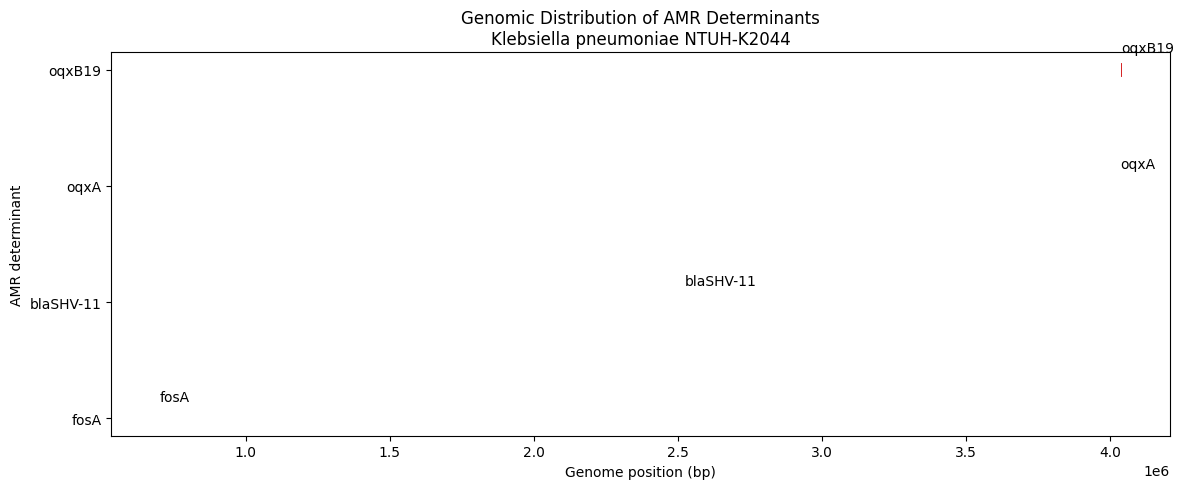

===== AMR REGION LENGTHS =====


,Element symbol,Start,Stop,Length
0,fosA,699857,700273,417
1,blaSHV-11,2524621,2525478,858
2,oqxA,4036312,4037484,1173
3,oqxB19,4037511,4040660,3150


In [34]:
# Step 37: Plot AMR determinants with a local genomic scale

import matplotlib.pyplot as plt

amr_plot = amr_evidence[
    ["Element symbol", "Start", "Stop"]
].copy()

amr_plot["Length"] = amr_plot["Stop"] - amr_plot["Start"] + 1

fig, ax = plt.subplots(figsize=(12, 5))

for i, row in amr_plot.iterrows():
    ax.plot(
        [row["Start"], row["Stop"]],
        [i, i],
        linewidth=10,
        solid_capstyle="butt"
    )

    ax.text(
        row["Start"],
        i + 0.15,
        row["Element symbol"],
        fontsize=10
    )

ax.set_yticks(range(len(amr_plot)))
ax.set_yticklabels(amr_plot["Element symbol"])

ax.set_xlabel("Genome position (bp)")
ax.set_ylabel("AMR determinant")
ax.set_title(
    "Genomic Distribution of AMR Determinants\n"
    "Klebsiella pneumoniae NTUH-K2044"
)

plt.tight_layout()
plt.show()

print("===== AMR REGION LENGTHS =====")
display(
    amr_plot[
        ["Element symbol", "Start", "Stop", "Length"]
    ].sort_values("Start")
)

In [36]:
# Step 38: Calculate accurate distance between AMR determinants

amr_positions = amr_evidence[
    ["Element symbol", "Start", "Stop"]
].copy()

amr_positions = amr_positions.sort_values("Start").reset_index(drop=True)

proximity_data = []

for i in range(1, len(amr_positions)):
    previous_gene = amr_positions.loc[i - 1, "Element symbol"]
    current_gene = amr_positions.loc[i, "Element symbol"]

    previous_stop = int(amr_positions.loc[i - 1, "Stop"])
    current_start = int(amr_positions.loc[i, "Start"])

    distance = current_start - previous_stop - 1

    proximity_data.append([
        previous_gene,
        current_gene,
        distance
    ])

proximity_table = pd.DataFrame(
    proximity_data,
    columns=[
        "Previous AMR determinant",
        "Next AMR determinant",
        "Distance (bp)"
    ]
)

print("===== DISTANCE BETWEEN AMR DETERMINANTS =====")
display(proximity_table)

===== DISTANCE BETWEEN AMR DETERMINANTS =====


,Previous AMR determinant,Next AMR determinant,Distance (bp)
0,fosA,blaSHV-11,1824347
1,blaSHV-11,oqxA,1510833
2,oqxA,oqxB19,26


In [37]:
# Step 39: Inspect genomic context around oqxA and oqxB19

oqx_cluster = biological_context[
    biological_context["AMR determinant"].isin(["oqxA", "oqxB19"])
].copy()

print("===== OQXA–OQXB19 GENOMIC CONTEXT =====")
display(oqx_cluster)

===== OQXA–OQXB19 GENOMIC CONTEXT =====


,AMR determinant,Gene/Locus tag,Product,Strand,Distance
6,oqxA,mexF,integral transmembrane protein for acridine re...,+,26
7,oqxA,KP1_4202,putative helix-turn-helix AraC-type trancripti...,-,333
8,oqxA,KP1_4201,hypothetical protein,+,706
9,oqxB19,mexE,putative multidrug efflux system membrane fusi...,+,24
10,oqxB19,KP1_4206,putative transcriptional regulator,-,72
11,oqxB19,KP1_4207,conserved hypothetical protein,-,825


In [38]:
# Step 40: Summarize genomic organization of the oqxA–oqxB19 region

oqx_summary = pd.DataFrame({
    "AMR determinant": ["oqxA", "oqxB19"],
    "Closest neighboring feature": ["mexF", "mexE"],
    "Distance to closest feature (bp)": [26, 24]
})

print("===== OQXA–OQXB19 GENOMIC ORGANIZATION SUMMARY =====")
display(oqx_summary)

===== OQXA–OQXB19 GENOMIC ORGANIZATION SUMMARY =====


,AMR determinant,Closest neighboring feature,Distance to closest feature (bp)
0,oqxA,mexF,26
1,oqxB19,mexE,24


In [39]:
# Step 41: Final genomic context interpretation

print("===== FINAL GENOMIC CONTEXT INTERPRETATION =====")

print("1. oqxA is located 26 bp from mexF.")
print("2. oqxB19 is located 24 bp from mexE.")
print("3. oqxA and oqxB19 are separated by 27 bp.")
print("4. These findings show that the two AMR determinants are located in a closely spaced genomic region.")
print("5. The genomic proximity provides contextual information but does not by itself prove that the neighboring genes cause antimicrobial resistance.")

===== FINAL GENOMIC CONTEXT INTERPRETATION =====
1. oqxA is located 26 bp from mexF.
2. oqxB19 is located 24 bp from mexE.
3. oqxA and oqxB19 are separated by 27 bp.
4. These findings show that the two AMR determinants are located in a closely spaced genomic region.
5. The genomic proximity provides contextual information but does not by itself prove that the neighboring genes cause antimicrobial resistance.


In [40]:
# Step 42: Create final AMR results table

final_amr_results = amr[
    [
        "Element symbol",
        "Element name",
        "Class",
        "Subclass",
        "Method",
        "% Coverage of reference",
        "% Identity to reference"
    ]
].copy()

print("===== FINAL AMR RESULTS =====")
display(final_amr_results)

===== FINAL AMR RESULTS =====


,Element symbol,Element name,Class,Subclass,Method,% Coverage of reference,% Identity to reference
0,fosA,FosA5 family fosfomycin resistance glutathione...,FOSFOMYCIN,FOSFOMYCIN,EXACTX,100.0,100.0
1,blaSHV-11,broad-spectrum class A beta-lactamase SHV-11,BETA-LACTAM,BETA-LACTAM,ALLELEX,100.0,100.0
2,oqxA,multidrug efflux RND transporter periplasmic a...,NITROFURAN/PHENICOL/QUINOLONE/TETRACYCLINE,NITROFURANTOIN/PHENICOL/QUINOLONE/TIGECYCLINE,EXACTX,100.0,100.0
3,oqxB19,multidrug efflux RND transporter permease subu...,PHENICOL/QUINOLONE,PHENICOL/QUINOLONE,ALLELEX,100.0,100.0


In [41]:
# Step 43: Final project conclusion

print("===== FINAL AMR ANALYSIS CONCLUSION =====")

print("Genome analyzed: Klebsiella pneumoniae NTUH-K2044")
print("Reference accession: AP006725.1")
print("AMR determinants detected: 4")
print("Detected determinants: fosA, blaSHV-11, oqxA, oqxB19")
print("Reference coverage: 100% for all detected determinants")
print("Reference identity: 100% for all detected determinants")
print("Genomic context: oqxA and oqxB19 are closely located, separated by 27 bp.")
print("Nearest features: mexF near oqxA (26 bp) and mexE near oqxB19 (24 bp).")
print("Limitation: Phenotypic antimicrobial susceptibility testing was not performed.")
print("Therefore, the analysis demonstrates genotypic AMR determinants but does not establish phenotypic antimicrobial resistance.")

===== FINAL AMR ANALYSIS CONCLUSION =====
Genome analyzed: Klebsiella pneumoniae NTUH-K2044
Reference accession: AP006725.1
AMR determinants detected: 4
Detected determinants: fosA, blaSHV-11, oqxA, oqxB19
Reference coverage: 100% for all detected determinants
Reference identity: 100% for all detected determinants
Genomic context: oqxA and oqxB19 are closely located, separated by 27 bp.
Nearest features: mexF near oqxA (26 bp) and mexE near oqxB19 (24 bp).
Limitation: Phenotypic antimicrobial susceptibility testing was not performed.
Therefore, the analysis demonstrates genotypic AMR determinants but does not establish phenotypic antimicrobial resistance.


In [42]:
# Step 44: Export final AMR results

final_amr_results.to_csv(
    "Klebsiella_NTUH-K2044_AMR_results.csv",
    index=False
)

print("Final AMR results saved successfully.")
print("File: Klebsiella_NTUH-K2044_AMR_results.csv")

Final AMR results saved successfully.
File: Klebsiella_NTUH-K2044_AMR_results.csv


In [43]:
# Step 45: Create final AMR analysis summary

final_summary = {
    "Organism": "Klebsiella pneumoniae NTUH-K2044",
    "Reference accession": "AP006725.1",
    "AMR determinants detected": 4,
    "Detected determinants": "fosA, blaSHV-11, oqxA, oqxB19",
    "Reference coverage": "100% for all detected determinants",
    "Reference identity": "100% for all detected determinants",
    "Closest genomic context": "oqxA–mexF (26 bp); oqxB19–mexE (24 bp)",
    "oqxA–oqxB19 distance": "27 bp",
    "Phenotypic susceptibility testing": "Not performed"
}

print("===== FINAL AMR ANALYSIS SUMMARY =====")
for key, value in final_summary.items():
    print(f"{key}: {value}")

===== FINAL AMR ANALYSIS SUMMARY =====
Organism: Klebsiella pneumoniae NTUH-K2044
Reference accession: AP006725.1
AMR determinants detected: 4
Detected determinants: fosA, blaSHV-11, oqxA, oqxB19
Reference coverage: 100% for all detected determinants
Reference identity: 100% for all detected determinants
Closest genomic context: oqxA–mexF (26 bp); oqxB19–mexE (24 bp)
oqxA–oqxB19 distance: 27 bp
Phenotypic susceptibility testing: Not performed


In [44]:
# Step 46: Export final AMR analysis summary

import pandas as pd

summary_table = pd.DataFrame(
    list(final_summary.items()),
    columns=["Parameter", "Result"]
)

summary_table.to_csv(
    "Klebsiella_NTUH-K2044_final_summary.csv",
    index=False
)

with open("Klebsiella_NTUH-K2044_final_report.txt", "w") as f:
    f.write("FINAL AMR ANALYSIS REPORT\n")
    f.write("=========================\n\n")

    for key, value in final_summary.items():
        f.write(f"{key}: {value}\n")

print("Final summary CSV saved successfully.")
print("Final report TXT saved successfully.")

Final summary CSV saved successfully.
Final report TXT saved successfully.


In [45]:
# Step 47: Verify exported final files

import os

files_to_check = [
    "Klebsiella_NTUH-K2044_AMR_results.csv",
    "Klebsiella_NTUH-K2044_final_summary.csv",
    "Klebsiella_NTUH-K2044_final_report.txt"
]

print("===== FINAL OUTPUT FILE VERIFICATION =====")

for file_name in files_to_check:
    if os.path.exists(file_name):
        file_size = os.path.getsize(file_name)
        print(f"✓ {file_name} | Size: {file_size} bytes")
    else:
        print(f"✗ {file_name} | NOT FOUND")

===== FINAL OUTPUT FILE VERIFICATION =====
✓ Klebsiella_NTUH-K2044_AMR_results.csv | Size: 603 bytes
✓ Klebsiella_NTUH-K2044_final_summary.csv | Size: 424 bytes
✓ Klebsiella_NTUH-K2044_final_report.txt | Size: 467 bytes


In [46]:
# Step 48: Create project README summary

readme_text = """
# Genotypic AMR Prediction in Klebsiella pneumoniae NTUH-K2044

## Objective
Identify antimicrobial resistance (AMR) determinants and examine their genomic context in
Klebsiella pneumoniae NTUH-K2044.

## Genome
- Organism: Klebsiella pneumoniae NTUH-K2044
- Reference accession: AP006725.1
- Genome length: 5,248,520 bp
- Annotated features: 10,280

## AMR determinants detected
Four AMR determinants were identified:
- fosA
- blaSHV-11
- oqxA
- oqxB19

## AMR evidence
All four detected determinants showed:
- 100% reference coverage
- 100% identity to reference

## Genomic context
- oqxA is 26 bp from mexF.
- oqxB19 is 24 bp from mexE.
- oqxA and oqxB19 are separated by 27 bp.

## Interpretation
The results demonstrate the presence of genotypic AMR determinants and their genomic
organization in the reference genome.

Genomic proximity provides contextual information but does not by itself prove that
neighboring genes cause antimicrobial resistance.

## Limitation
Phenotypic antimicrobial susceptibility testing was not performed.
Therefore, this analysis does not establish phenotypic antimicrobial resistance.

## Output files
- Klebsiella_NTUH-K2044_AMR_results.csv
- Klebsiella_NTUH-K2044_final_summary.csv
- Klebsiella_NTUH-K2044_final_report.txt
"""

with open("README.md", "w") as f:
    f.write(readme_text)

print("README.md created successfully.")

README.md created successfully.


In [47]:
# Step 49: Final project file check

import os

project_files = [
    "README.md",
    "Klebsiella_NTUH-K2044_AMR_results.csv",
    "Klebsiella_NTUH-K2044_final_summary.csv",
    "Klebsiella_NTUH-K2044_final_report.txt"
]

print("===== FINAL PROJECT FILE CHECK =====")

all_present = True

for file_name in project_files:
    if os.path.exists(file_name):
        print(f"✓ {file_name}")
    else:
        print(f"✗ {file_name} - NOT FOUND")
        all_present = False

print()

if all_present:
    print("FINAL PROJECT CHECK: PASSED")
else:
    print("FINAL PROJECT CHECK: INCOMPLETE")

===== FINAL PROJECT FILE CHECK =====
✓ README.md
✓ Klebsiella_NTUH-K2044_AMR_results.csv
✓ Klebsiella_NTUH-K2044_final_summary.csv
✓ Klebsiella_NTUH-K2044_final_report.txt

FINAL PROJECT CHECK: PASSED
